# 0. Setup & Data Loading

In [258]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import re


# Get project root (one level above notebooks/)
project_root = Path().resolve().parent

# Add project root to Python path if not already there
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root:", project_root)
print("src exists:", (project_root / "src").exists())

Project root: C:\Users\Techtop\Desktop\NOVA\S2.1\Data Ecosystems & Govern\dego-project-teamTXA1
src exists: True


In [259]:
from src.data_loading import load_raw_data

df = load_raw_data()
df.shape

(502, 21)

In [260]:
df
df.to_csv("full_dataset_view.csv", index=False)

# 1. Data Quality Assessment

This notebook evaluates the data quality of the raw_credit_applications.json dataset.

The objectives are to:

- Identify data quality issues  
- Quantify the extent of each issue   
- Prepare remediation steps for the cleaning pipeline  

In [261]:
df.head()

,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,...,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,...,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,...,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,...,70,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,...,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN


In [262]:
# Get all columns from the raw dataframe
all_columns = df.columns.tolist()
print("Raw columns:", all_columns)

# Save group keys based on original prefixes
group_keys = {
    "_id": [],
    "applicant_info": [col for col in all_columns if col.startswith("applicant_info")],
    "financials":     [col for col in all_columns if col.startswith("financials")],
    "spending_behavior": [col for col in all_columns if col.startswith("spending_behavior")],
    "decision":       [col for col in all_columns if col.startswith("decision")],
}

print("\n=== GROUP KEYS ===")
for group, keys in group_keys.items():
    print(f"\n{group}:")
    if group == "_id":
        print(f"  - _id")
    for k in keys:
        print(f"  - {k}")

Raw columns: ['_id', 'spending_behavior', 'processing_timestamp', 'applicant_info.full_name', 'applicant_info.email', 'applicant_info.ssn', 'applicant_info.ip_address', 'applicant_info.gender', 'applicant_info.date_of_birth', 'applicant_info.zip_code', 'financials.annual_income', 'financials.credit_history_months', 'financials.debt_to_income', 'financials.savings_balance', 'decision.loan_approved', 'decision.rejection_reason', 'loan_purpose', 'decision.interest_rate', 'decision.approved_amount', 'financials.annual_salary', 'notes']

=== GROUP KEYS ===

_id:
  - _id

applicant_info:
  - applicant_info.full_name
  - applicant_info.email
  - applicant_info.ssn
  - applicant_info.ip_address
  - applicant_info.gender
  - applicant_info.date_of_birth
  - applicant_info.zip_code

financials:
  - financials.annual_income
  - financials.credit_history_months
  - financials.debt_to_income
  - financials.savings_balance
  - financials.annual_salary

spending_behavior:
  - spending_behavior

decis

In [263]:
# Rename columns
df.columns = df.columns.str.replace(r"^(financials\.|applicant_info\.|decision\.)", "", regex=True)

# Confirm
print(df.columns.tolist())

# ---- UPDATE GROUP KEYS TO CLEAN NAMES ----
group_keys_clean = {
    group: [
        re.sub(r"^(financials\.|applicant_info\.|decision\.)", "", col)
        for col in keys
    ]
    for group, keys in group_keys.items()
}

print("\n=== GROUP KEYS (CLEAN NAMES) ===")
for group, keys in group_keys_clean.items():
    print(f"\n{group}:")
    if group == "_id":
        print(f"  - _id")
    for k in keys:
        print(f"  - {k}")

['_id', 'spending_behavior', 'processing_timestamp', 'full_name', 'email', 'ssn', 'ip_address', 'gender', 'date_of_birth', 'zip_code', 'annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance', 'loan_approved', 'rejection_reason', 'loan_purpose', 'interest_rate', 'approved_amount', 'annual_salary', 'notes']

=== GROUP KEYS (CLEAN NAMES) ===

_id:
  - _id

applicant_info:
  - full_name
  - email
  - ssn
  - ip_address
  - gender
  - date_of_birth
  - zip_code

financials:
  - annual_income
  - credit_history_months
  - debt_to_income
  - savings_balance
  - annual_salary

spending_behavior:
  - spending_behavior

decision:
  - loan_approved
  - rejection_reason
  - interest_rate
  - approved_amount


In [264]:
df.dtypes

_id                       object
spending_behavior         object
processing_timestamp      object
full_name                 object
email                     object
ssn                       object
ip_address                object
gender                    object
date_of_birth             object
zip_code                  object
annual_income             object
credit_history_months      int64
debt_to_income           float64
savings_balance            int64
loan_approved               bool
rejection_reason          object
loan_purpose              object
interest_rate            float64
approved_amount          float64
annual_salary            float64
notes                     object
dtype: object

We can see that `annual_income` has the wrong data type and needs to be converted to `float`.

# 1.1 Completeness

In [265]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = (
    missing_counts.to_frame("missing_count")
    .join(missing_percent.to_frame("missing_percent"))
)

# Add percentage sign
missing_summary["missing_percent"] = (
    missing_summary["missing_percent"]
    .round(2)
    .astype(str) + " %"
)

missing_summary[missing_summary["missing_count"] > 0].head(20)

,missing_count,missing_percent
notes,500,99.6 %
annual_salary,497,99.0 %
loan_purpose,452,90.04 %
processing_timestamp,440,87.65 %
rejection_reason,292,58.17 %
interest_rate,210,41.83 %
approved_amount,210,41.83 %
ssn,5,1.0 %
ip_address,5,1.0 %
annual_income,5,1.0 %


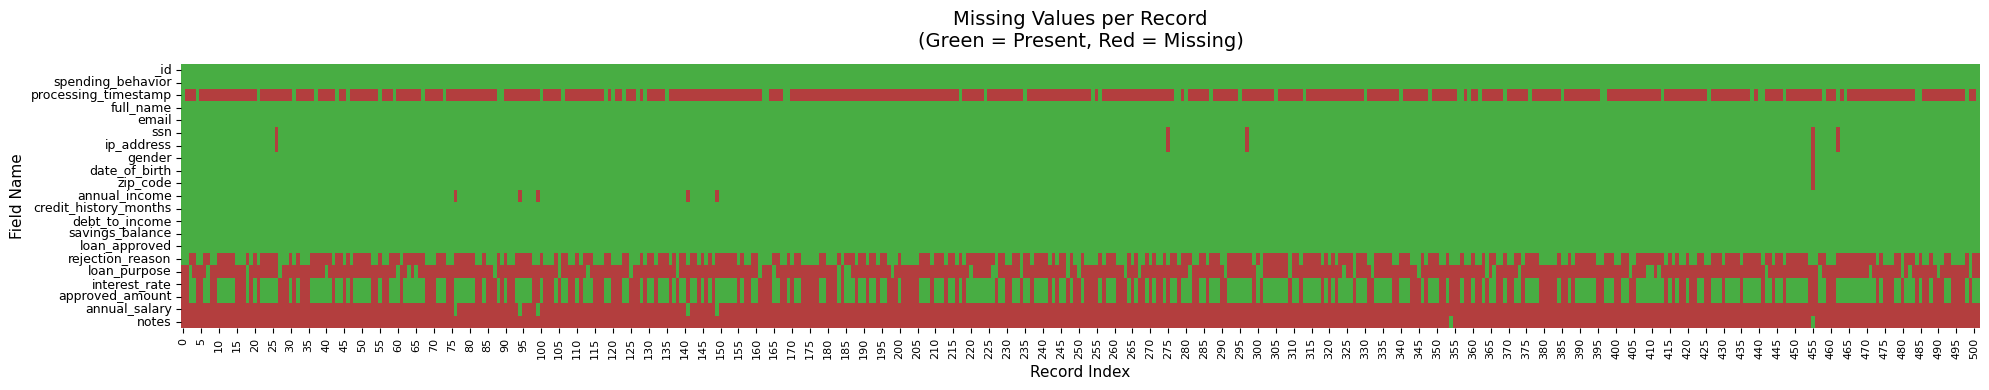

In [266]:
# Missing Values Heatmap
# Green = Present | Red = Missing

presence = df.notna().astype(int)

fig, ax = plt.subplots(figsize=(20, 4))

sns.heatmap(
    presence.T,
    cmap=["#B33E3E", "#48ad43"],   # dark gray = missing, green = present
    cbar=False,
    linewidths=0,
    ax=ax
)

ax.set_title(
    'Missing Values per Record\n(Green = Present, Red = Missing)',
    fontsize=14,
    pad=12
)

ax.set_xlabel('Record Index', fontsize=11)
ax.set_ylabel('Field Name', fontsize=11)

ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(
    '../reports/missing_value_heatmap.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

The `annual_salary` column will be merged into the `annual_income` column, as they represent the same data. All non-empty values from `annual_salary` are already reflected in `annual_salary`, after which it will be removed from the dataset.

# 1.2 Consistency

In [267]:
total_rows = len(df)

duplicate_mask = df.duplicated(subset="_id", keep="first")

duplicate_count = duplicate_mask.sum()
duplicate_percent = duplicate_count / total_rows * 100

duplicate_summary = pd.DataFrame({
    "count": [duplicate_count],
    "percent": [f"{duplicate_percent:.2f} %"]
}, index=["duplicate rows"])

duplicate_summary

,count,percent
duplicate rows,2,0.40 %


In [292]:
gender_counts = df["gender"].value_counts(dropna=False)

gender_percent = (
    df["gender"]
    .value_counts(normalize=True, dropna=False) * 100
)

gender_summary = pd.DataFrame({
    "count": gender_counts,
    "percent": gender_percent.round(2).astype(str) + " %"
})

gender_summary

,count,percent
gender,,
Male,195,38.84 %
Female,193,38.45 %
F,58,11.55 %
M,53,10.56 %
,2,0.4 %
NaN,1,0.2 %


The `gender` column contains 5 distinct values, indicating inconsistent data entry.

In [269]:
df_clean = df.copy()
df_clean["gender"] = (
    df_clean["gender"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "m": "male",
        "f": "female",
        "nan": None,     # convert string "nan" back to missing
        "": None         # convert empty string to missing
    })
)

# Drop rows where gender is missing after cleaning
df_clean = df_clean.dropna(subset=["gender"])

df_clean["gender"].value_counts(dropna=False)

gender
female    251
male      248
Name: count, dtype: int64

In [ ]:
col = "date_of_birth"

s = df_clean[col].astype("string").str.strip()

# Important: explicitly set dtype to datetime
parsed = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")

# 1) YYYY/MM/DD
mask_year_slash = s.str.match(r"^\d{4}/\d{2}/\d{2}$", na=False)
parsed.loc[mask_year_slash] = pd.to_datetime(s.loc[mask_year_slash], format="%Y/%m/%d", errors="coerce")

# 2) DD/MM/YYYY
mask_us_slash = s.str.match(r"^\d{2}/\d{2}/\d{4}$", na=False)
parsed.loc[mask_us_slash] = pd.to_datetime(s.loc[mask_us_slash], format="%d/%m/%Y", errors="coerce")

# 3) YYYY-MM-DD
mask_iso_hyphen = s.str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)
parsed.loc[mask_iso_hyphen] = pd.to_datetime(s.loc[mask_iso_hyphen], format="%Y-%m-%d", errors="coerce")

# 2b) Reparse remaining slash dates as MM/DD/YYYY
remaining_slash = (
    parsed.isna()
    & s.notna()
    & s.str.match(r"^\d{2}/\d{2}/\d{4}$", na=False)
)
parsed.loc[remaining_slash] = pd.to_datetime(s.loc[remaining_slash], format="%m/%d/%Y", errors="coerce")

# 4) Standardize format as string
df_clean[col] = parsed.dt.strftime("%Y-%m-%d").astype("object")

# ---- FORMAT CHECK AFTER CLEANING ----
s_clean = df_clean[col].astype("string").str.strip()
format_patterns = s_clean.str.replace(r"\d", "D", regex=True)
pattern_counts = format_patterns.value_counts(dropna=False)
pattern_percent = (pattern_counts / len(s_clean) * 100).round(2)

pattern_summary = pd.DataFrame({
    "count": pattern_counts,
    "percent": pattern_percent.map(lambda x: f"{x} %")
})

print("=== DATE FORMAT AFTER CLEANING ===")
display(pattern_summary)
```

If everything worked correctly you should now see **only one pattern**:
```
                count    percent
DDDD-DD-DD        497     99.2 %
NaN                 4      0.8 %

,count,percent
date_of_birth,,
DDDD-DD-DD,340,67.86 %
DD/DD/DDDD,101,20.16 %
DDDD/DD/DD,56,11.18 %
,4,0.8 %


The `date_of_birth` column contains 4 distinct values, indicating inconsistent data entry.

In [290]:
col = "date_of_birth"

s = df[col].astype("string").str.strip()

# Important: explicitly set dtype to datetime
parsed = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")

# 1) YYYY/MM/DD
mask_year_slash = s.str.match(r"^\d{4}/\d{2}/\d{2}$", na=False)

parsed.loc[mask_year_slash] = pd.to_datetime(
    s.loc[mask_year_slash],
    format="%Y/%m/%d",
    errors="coerce",
)

# 2) XX/XX/XXXX → assume MONTH/DAY/YEAR
mask_us_slash = s.str.match(r"^\d{2}/\d{2}/\d{4}$", na=False)

parsed.loc[mask_us_slash] = pd.to_datetime(
    s.loc[mask_us_slash],
    format="%d/%m/%Y",   
    errors="coerce",
)

# 3) YYYY-MM-DD
mask_iso_hyphen = s.str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)

parsed.loc[mask_iso_hyphen] = pd.to_datetime(
    s.loc[mask_iso_hyphen],
    format="%Y-%m-%d",
    errors="coerce",
)

# 2b) Re parse remaining slash dates as month/day/year for the tricky ones
remaining_slash = (
    parsed.isna()
    & s.notna()
    & s.str.match(r"^\d{2}/\d{2}/\d{4}$", na=False)
)

parsed.loc[remaining_slash] = pd.to_datetime(
    s.loc[remaining_slash],
    format="%m/%d/%Y",
    errors="coerce",
)

# 4) Standardize format
df_clean[col] = parsed.dt.strftime("%Y-%m-%d")

# ---- FORMAT CHECK AFTER CLEANING ----
s_clean = df_clean[col].astype("string").str.strip()

format_patterns = s_clean.str.replace(r"\d", "D", regex=True)

pattern_counts = format_patterns.value_counts(dropna=False)
pattern_percent = (pattern_counts / len(s_clean) * 100).round(2)

pattern_summary = pd.DataFrame({
    "count": pattern_counts,
    "percent": pattern_percent.map(lambda x: f"{x} %")
})

print("=== DATE FORMAT AFTER CLEANING ===")
display(pattern_summary)

=== DATE FORMAT AFTER CLEANING ===


,count,percent
date_of_birth,,
DDDD-DD-DD,493,99.0 %
<NA>,5,1.0 %


In [272]:
col_amount = "approved_amount"
col_decision = "loan_approved"

# Convert to numeric safely
amount_num = pd.to_numeric(df[col_amount], errors="coerce")

# Rule A: Approved but amount <= 0 or missing
invalid_approved = (
    (df[col_decision] == True) &
    ((amount_num <= 0) | (amount_num.isna()))
)

# Rule B: Not approved but has positive amount
invalid_not_approved = (
    (df[col_decision] == False) &
    (amount_num > 0)
)

# Combine both issues
invalid_mask = invalid_approved | invalid_not_approved

invalid_count = invalid_mask.sum()
invalid_percent = invalid_count / len(df) * 100

invalid_summary = pd.DataFrame({
    "count": [invalid_count],
    "percent": [f"{round(invalid_percent, 2)} %"]
}, index=["Approved amount / decision inconsistency"])

invalid_summary

,count,percent
Approved amount / decision inconsistency,0,0.0 %


Merged and removed duplicated rows.

In [273]:
df_clean = df.copy()

# ---- BEFORE ----
duplicate_ids = df_clean[df_clean.duplicated(subset="_id", keep=False)]["_id"].unique()

rows_before = df_clean[df_clean["_id"].isin(duplicate_ids)].sort_values("_id")
print("BEFORE CLEANING:")
display(rows_before)

# ---- CLEAN ----
df_clean = (
    df_clean
    .sort_values("_id")
    .groupby("_id", sort=False)
    .apply(lambda g: g.ffill().bfill().iloc[0], include_groups=False)
    .reset_index()
)

# ---- AFTER ----
rows_after = df_clean[df_clean["_id"].isin(duplicate_ids)].sort_values("_id")
print("AFTER CLEANING:")
display(rows_after)

BEFORE CLEANING:


,_id,spending_behavior,processing_timestamp,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,...,credit_history_months,debt_to_income,savings_balance,loan_approved,rejection_reason,loan_purpose,interest_rate,approved_amount,annual_salary,notes
383,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,Female,1986-05-27,90230,...,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,NaN
455,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,NaN,NaN,NaN,NaN,NaN,...,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,DUPLICATE_ENTRY_ERROR
8,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,...,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
354,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,...,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,RESUBMISSION


C:\Users\Techtop\AppData\Local\Temp\ipykernel_18588\3337802759.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .apply(lambda g: g.ffill().bfill().iloc[0], include_groups=False)


AFTER CLEANING:


,_id,spending_behavior,processing_timestamp,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,...,credit_history_months,debt_to_income,savings_balance,loan_approved,rejection_reason,loan_purpose,interest_rate,approved_amount,annual_salary,notes
0,app_001,"[{'category': 'Fitness', 'amount': 576}]",NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,Female,1986-05-27,90230,...,37,0.42,0,False,high_dti_ratio,NaN,NaN,NaN,NaN,DUPLICATE_ENTRY_ERROR
41,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,...,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,RESUBMISSION


Standardized `date_of_birth` column

In [274]:
df_clean["gender"] = (
    df_clean["gender"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "m": "male",
        "f": "female",
        "nan": None,     # convert string "nan" back to missing
        "": None         # convert empty string to missing
    })
)

# Drop rows where gender is missing after cleaning
df_clean = df_clean.dropna(subset=["gender"])

df_clean["gender"].value_counts(dropna=False)

gender
female    251
male      247
Name: count, dtype: int64

In [275]:
df_clean = df_clean.copy()

income_col = "annual_income"
salary_col = "annual_salary"

# ---- BEFORE ----
print("=== BEFORE ===")
print(f"{income_col} dtype: {df_clean[income_col].dtype}")
print(f"{income_col} null count: {df_clean[income_col].isna().sum()}")
print(f"{salary_col} dtype: {df_clean[salary_col].dtype}")
print(f"{salary_col} null count: {df_clean[salary_col].isna().sum()}")

# Ensure both are numeric
df_clean[income_col] = pd.to_numeric(df_clean[income_col], errors="coerce")
df_clean[salary_col] = pd.to_numeric(df_clean[salary_col], errors="coerce")

# Count how many salary values exist
salary_non_null = df_clean[salary_col].notna().sum()

# Move salary into income ONLY where income is missing
mask_move = df_clean[income_col].isna() & df_clean[salary_col].notna()
moved_count = mask_move.sum()

df_clean.loc[mask_move, income_col] = df_clean.loc[mask_move, salary_col]

# Drop salary column
df_clean = df_clean.drop(columns=[salary_col])

# ---- AFTER ----
print("\n=== AFTER ===")
print(f"{income_col} dtype: {df_clean[income_col].dtype}")
print(f"{income_col} null count: {df_clean[income_col].isna().sum()}")
print(f"Salary values found: {salary_non_null}")
print(f"Values moved to annual_income: {moved_count}")

=== BEFORE ===
annual_income dtype: object
annual_income null count: 5
annual_salary dtype: float64
annual_salary null count: 493

=== AFTER ===
annual_income dtype: float64
annual_income null count: 0
Salary values found: 5
Values moved to annual_income: 5


Merged `annual_salary` with `annual_income`, removed `annual_income` and changed the type of the column from object to float.

# 1.3 Validity

In [276]:
col = "credit_history_months"

history_num = pd.to_numeric(df[col], errors="coerce")

invalid_mask = history_num < 0

invalid_count = invalid_mask.sum()
invalid_percent = invalid_count / len(df) * 100

invalid_summary = pd.DataFrame({
    "count": [invalid_count],
    "percent": [f"{round(invalid_percent, 2)} %"]
}, index=["credit_history_months < 0"])

invalid_summary

,count,percent
credit_history_months < 0,2,0.4 %


In [278]:
col = "savings_balance"

savings_num = pd.to_numeric(df[col], errors="coerce")

invalid_mask = savings_num < 0

invalid_count = invalid_mask.sum()
invalid_percent = invalid_count / len(df) * 100

invalid_summary = pd.DataFrame({
    "count": [invalid_count],
    "percent": [f"{round(invalid_percent, 2)} %"]
}, index=["savings_balance < 0"])

invalid_summary

,count,percent
savings_balance < 0,1,0.2 %


In [279]:
col = "debt_to_income"

dti_num = pd.to_numeric(df[col], errors="coerce")

invalid_mask = dti_num > 0.5

invalid_count = invalid_mask.sum()
invalid_percent = invalid_count / len(df) * 100

invalid_summary = pd.DataFrame({
    "count": [invalid_count],
    "percent": [f"{round(invalid_percent, 2)} %"]
}, index=["debt_to_income < 0"])  # Fixed: updated index label

invalid_summary

,count,percent
debt_to_income < 0,1,0.2 %


In [280]:
df_clean.to_csv("clean_dataset_view.csv", index=False)

In [281]:
print(df_clean.columns.tolist())

['_id', 'spending_behavior', 'processing_timestamp', 'full_name', 'email', 'ssn', 'ip_address', 'gender', 'date_of_birth', 'zip_code', 'annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance', 'loan_approved', 'rejection_reason', 'loan_purpose', 'interest_rate', 'approved_amount', 'notes']


Set Nan for financial data below 0

In [282]:
cols = ["savings_balance", "credit_history_months", "annual_income", "debt_to_income"]

df_clean.loc[df_clean["savings_balance"] < 0, "savings_balance"] = np.nan
df_clean.loc[df_clean["credit_history_months"] < 0, "credit_history_months"] = np.nan
df_clean.loc[df_clean["annual_income"] < 0, "annual_income"] = np.nan
df_clean.loc[df_clean["debt_to_income"] > 0.5, "debt_to_income"] = np.nan

In [283]:
# Convert processing_timestamp to datetime
df_clean["processing_timestamp"] = pd.to_datetime(
    df_clean["processing_timestamp"],
    errors="coerce"
)

# Convert date_of_birth to datetime
df_clean["date_of_birth"] = pd.to_datetime(
    df_clean["date_of_birth"],
    errors="coerce"
)

print(df_clean["processing_timestamp"].dtype)
print(df_clean["date_of_birth"].dtype)

datetime64[ns, UTC]
datetime64[ns]


Change the invalid emails to Nan

In [284]:
invalid_email_mask = ~df_clean["email"].astype(str).apply(
    lambda x: bool(re.match(r"^[\w\.-]+@[\w\.-]+\.\w+$", x))
)

invalid_emails = df_clean[invalid_email_mask][["_id", "full_name", "email"]]

print(f"Total invalid emails: {invalid_email_mask.sum()}")
display(invalid_emails)

Total invalid emails: 9


,_id,full_name,email
67,app_068,Emily Lopez,john.doe@invalid
119,app_120,Carolyn Martin,
145,app_146,Amy Flores,sarah.smith@
164,app_165,Brandon Moore,
203,app_204,Jonathan Carter,mike johnson@gmail.com
298,app_299,Samuel Gonzalez,test.user.outlook.com
349,app_350,Linda Adams,
376,app_377,Anna White,
412,app_413,Anthony Jackson,


In [285]:
invalid_email_mask = ~df_clean["email"].astype(str).apply(
    lambda x: bool(re.match(r"^[\w\.-]+@[\w\.-]+\.\w+$", x))
)

print(f"Invalid emails replaced with NaN: {invalid_email_mask.sum()}")

df_clean.loc[invalid_email_mask, "email"] = np.nan

Invalid emails replaced with NaN: 9


In [291]:
# ---- TYPE VALIDATION PER COLUMN ----

def validate_column(series, col_name, check_fn, expected_desc):
    """Run a validation check and return a summary row."""
    try:
        invalid_mask = ~series.dropna().apply(check_fn)
        invalid_count = invalid_mask.sum()
        total = series.notna().sum()
        status = "✅ OK" if invalid_count == 0 else "❌ Issues found"
        return {
            "column": col_name,
            "expected": expected_desc,
            "invalid_count": invalid_count,
            "valid_count": total - invalid_count,
            "null_count": series.isna().sum(),
            "status": status
        }
    except Exception as e:
        return {
            "column": col_name,
            "expected": expected_desc,
            "invalid_count": "ERROR",
            "valid_count": "ERROR",
            "null_count": series.isna().sum(),
            "status": f"❌ {str(e)}"
        }


results = []

# _id — should be string starting with "app_"
results.append(validate_column(
    df_clean["_id"], "_id",
    lambda x: isinstance(x, str) and bool(re.match(r"^app_\d+$", x)),
    "string matching 'app_XXX'"
))

# spending_behavior — should be a list of dicts with 'category' and 'amount'
results.append(validate_column(
    df_clean["spending_behavior"], "spending_behavior",
    lambda x: isinstance(x, list) and all("category" in i and "amount" in i for i in x),
    "list of dicts with 'category' and 'amount'"
))

# full_name — should be non-empty string
results.append(validate_column(
    df_clean["full_name"], "full_name",
    lambda x: isinstance(x, str) and len(x.strip()) > 0,
    "non-empty string"
))

# email — should contain @ and .
results.append(validate_column(
    df_clean["email"], "email",
    lambda x: bool(re.match(r"^[\w\.-]+@[\w\.-]+\.\w+$", str(x))),
    "valid email format"
))

# ssn — should match XXX-XX-XXXX
results.append(validate_column(
    df_clean["ssn"], "ssn",
    lambda x: bool(re.match(r"^\d{3}-\d{2}-\d{4}$", str(x))),
    "format XXX-XX-XXXX"
))

# ip_address — should match IP pattern
results.append(validate_column(
    df_clean["ip_address"], "ip_address",
    lambda x: bool(re.match(r"^\d{1,3}(\.\d{1,3}){3}$", str(x))),
    "valid IP address"
))

# gender — should be male or female only
results.append(validate_column(
    df_clean["gender"], "gender",
    lambda x: str(x).lower() in ["male", "female"],
    "male or female"
))

# date_of_birth — should match YYYY-MM-DD
results.append(validate_column(
    df_clean["date_of_birth"], "date_of_birth",
    lambda x: pd.notna(pd.to_datetime(x, errors="coerce")),
    "valid date (YYYY-MM-DD)"
))

# zip_code — should be 5 digits
results.append(validate_column(
    df_clean["zip_code"], "zip_code",
    lambda x: bool(re.match(r"^\d{5}$", str(x))),
    "5 digit number"
))

# annual_income — should be positive number
results.append(validate_column(
    df_clean["annual_income"], "annual_income",
    lambda x: pd.to_numeric(x, errors="coerce") >= 0,
    "positive number"
))

# credit_history_months — should be >= 0
results.append(validate_column(
    df_clean["credit_history_months"], "credit_history_months",
    lambda x: pd.to_numeric(x, errors="coerce") >= 0,
    "non-negative number"
))

# debt_to_income — should be between 0 and 0.5
results.append(validate_column(
    df_clean["debt_to_income"], "debt_to_income",
    lambda x: 0 <= pd.to_numeric(x, errors="coerce") <= 0.5,
    "number between 0 and 0.5"
))

# savings_balance — should be >= 0
results.append(validate_column(
    df_clean["savings_balance"], "savings_balance",
    lambda x: pd.to_numeric(x, errors="coerce") >= 0,
    "non-negative number"
))

# loan_approved — should be boolean
results.append(validate_column(
    df_clean["loan_approved"], "loan_approved",
    lambda x: str(x).capitalize() in ["True", "False"],
    "True or False"
))

# rejection_reason — should be string or null (no validation needed, just null check)
results.append({
    "column": "rejection_reason",
    "expected": "string or null",
    "invalid_count": 0,
    "valid_count": df_clean["rejection_reason"].notna().sum(),
    "null_count": df_clean["rejection_reason"].isna().sum(),
    "status": "✅ OK"
})

# loan_purpose — should be string or null
results.append({
    "column": "loan_purpose",
    "expected": "string or null",
    "invalid_count": 0,
    "valid_count": df_clean["loan_purpose"].notna().sum(),
    "null_count": df_clean["loan_purpose"].isna().sum(),
    "status": "✅ OK"
})

# interest_rate — should be positive number
results.append(validate_column(
    df_clean["interest_rate"], "interest_rate",
    lambda x: pd.to_numeric(x, errors="coerce") > 0,
    "positive number"
))

# approved_amount — should be >= 0
results.append(validate_column(
    df_clean["approved_amount"], "approved_amount",
    lambda x: pd.to_numeric(x, errors="coerce") >= 0,
    "non-negative number"
))

# notes — should be string or null
results.append({
    "column": "notes",
    "expected": "string or null",
    "invalid_count": 0,
    "valid_count": df_clean["notes"].notna().sum(),
    "null_count": df_clean["notes"].isna().sum(),
    "status": "✅ OK"
})

# ---- SUMMARY ----
validation_summary = pd.DataFrame(results)
display(validation_summary)

passed = (validation_summary["status"] == "✅ OK").sum()
failed = (validation_summary["status"] != "✅ OK").sum()
print(f"\nPassed: {passed} / {len(validation_summary)}")
print(f"Failed: {failed} / {len(validation_summary)}")

,column,expected,invalid_count,valid_count,null_count,status
0,_id,string matching 'app_XXX',0,498,0,✅ OK
1,spending_behavior,list of dicts with 'category' and 'amount',0,498,0,✅ OK
2,full_name,non-empty string,0,498,0,✅ OK
3,email,valid email format,0,489,9,✅ OK
4,ssn,format XXX-XX-XXXX,0,496,2,✅ OK
5,ip_address,valid IP address,0,496,2,✅ OK
6,gender,male or female,0,498,0,✅ OK
7,date_of_birth,valid date (YYYY-MM-DD),0,493,5,✅ OK
8,zip_code,5 digit number,0,498,0,✅ OK
9,annual_income,positive number,0,498,0,✅ OK



Passed: 19 / 19
Failed: 0 / 19


# 1.4 Accuracy

Age plausibility check

In [250]:
df_clean["date_of_birth"] = pd.to_datetime(df_clean["date_of_birth"], errors="coerce")

df_clean["age"] = (pd.Timestamp.now() - df_clean["date_of_birth"]).dt.days // 365

# Exclude NaNs, only flag implausible computed ages
invalid_age_mask = df_clean["age"].notna() & ~df_clean["age"].between(18, 100)

print(f"Implausible ages (excluding NaN): {invalid_age_mask.sum()}")
df_clean[invalid_age_mask][["_id", "date_of_birth", "age"]]

Implausible ages (excluding NaN): 0


,_id,date_of_birth,age


Cross-field plausibility

In [251]:
computed_dti = df_clean["savings_balance"] / df_clean["annual_income"]
discrepancy = (computed_dti - df_clean["debt_to_income"]).abs()
print(f"Large DTI discrepancies: {(discrepancy > 0.1).sum()}")

Large DTI discrepancies: 319


Duplicate SSN with different names

In [252]:
ssn_name = df_clean.groupby("ssn")["full_name"].nunique()
suspicious = ssn_name[ssn_name > 1]
print(f"SSNs with multiple names: {len(suspicious)}")
df_clean[df_clean["ssn"].isin(suspicious.index)][["_id", "ssn", "full_name"]]

SSNs with multiple names: 2


,_id,ssn,full_name
15,app_016,780-24-9300,Gary Wilson
87,app_088,780-24-9300,Susan Martinez
100,app_101,937-72-8731,Sandra Smith
233,app_234,937-72-8731,Samuel Hill


 Timestamp plausibility 

In [253]:
now = pd.Timestamp.now(tz="UTC")
future_mask = df_clean["processing_timestamp"] > now
old_mask = df_clean["processing_timestamp"] < pd.Timestamp("2000-01-01", tz="UTC")

print(f"Future timestamps: {future_mask.sum()}")
print(f"Unrealistically old timestamps: {old_mask.sum()}")

Future timestamps: 2
Unrealistically old timestamps: 0


In [254]:
df_clean.to_csv("clean_dataset_view.csv", index=False)